In [2]:
%pip install numpy
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import time

In [19]:
def counter(func):
    '''times how long a function takes to run'''
    def inner(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()

        print(f'Function time elapsed:  {end - start}')
        return result, end-start
    return inner

In [20]:
@counter
def monte_carlo_pi(n):
    '''estimate pi using monte carlo method'''
    inside = 0
    for i in range(n):
        x, y = np.random.random(2)
        if np.sqrt((x**2 + y**2)) < 1:
            inside += 1

    pi = 4 * (inside / n)
    return pi


In [21]:
@counter
def monte_carlo_pi_2(n):
    inside = 0
    points = np.random.random((n, 2))
    points_squared = np.square(points)
    sums = points_squared[:,0] + points_squared[:,1]
    final_arr = np.delete(sums, np.where(sums >= 1))

    return 4 * (len(final_arr) / n)


    
    
    

In [22]:
print(monte_carlo_pi_2(1000))

print(monte_carlo_pi(1000))

Function time elapsed:  0.0015082359313964844
(3.128, 0.0015082359313964844)
Function time elapsed:  0.005585908889770508
(3.168, 0.005585908889770508)


Function time elapsed:  0.0007140636444091797
Function time elapsed:  0.0011153221130371094
Function time elapsed:  0.0004260540008544922
Function time elapsed:  0.0069675445556640625
Function time elapsed:  0.04471302032470703
Function time elapsed:  0.2743089199066162
Function time elapsed:  0.00010037422180175781
Function time elapsed:  3.719329833984375e-05
Function time elapsed:  4.3392181396484375e-05
Function time elapsed:  0.00022912025451660156
Function time elapsed:  0.00022220611572265625
Function time elapsed:  0.0032279491424560547


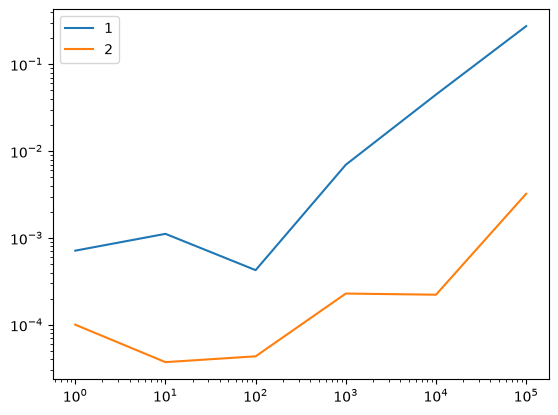

In [31]:
denoms = [1, 10, 100, 1000, 10_000, 100_000]

y_1 = [monte_carlo_pi(d)[1] for d in denoms]
y_2 = [monte_carlo_pi_2(d)[1] for d in denoms]

plt.plot(denoms, y_1, label='1')
plt.plot(denoms, y_2, label='2')

plt.xscale('log')
plt.yscale('log')

plt.legend()